Minimal code needed for data collection from GitHub API

In [ ]:
import os
from dotenv import load_dotenv
from src.mlProject.entity import RepositoriesAnalytics, GitHubClient

load_dotenv()
client = GitHubClient(token=os.getenv("GITHUB_TOKEN"))
analytics = RepositoriesAnalytics(client=client)
analytics.collect_repository_data_for_search(client, query="machine learning", sort="stars")

Minimal code needed for retrieving previously collected repositories from CSV

In [ ]:
import os
from dotenv import load_dotenv
from src.mlProject.entity import RepositoriesAnalytics, GitHubClient

load_dotenv()
client = GitHubClient(token=os.getenv("GITHUB_TOKEN"))
analytics_from_csv = RepositoriesAnalytics.from_csv("data", client=client)

Data collection from GitHub API with timing and saving to CSV. Retrieves previously collected repositories.

In [ ]:
from src.mlProject.entity import RepositoriesAnalytics, GitHubClient, RepositorySummary
from src.mlProject.constants import REPOSITORY_FEATURES, SUPPORTED_LANGUAGES
from time import time
from dotenv import load_dotenv
import os

load_dotenv()
client = GitHubClient(token=os.getenv("GITHUB_TOKEN"))
analytics = RepositoriesAnalytics.from_csv(folder_path="data", client=client)
queries = [ "gaming", "machine learning", "biology", "cybersecurity", "web development", "data science", "mobile development", "devops", "blockchain", "internet of things" ]

start = time()
processed_count = 0
# I am saving during the loop to avoid losing data if the process is interrupted
for query in [queries[8]]:  # Limiting to first 2 queries for testing
    # Collect repositories sorted by stars
    processed_count += analytics.collect_repository_data_for_search(
        client,
        query=query,
        sort="stars",
        n_releases=12)
    analytics.to_csv("data")

    # Collect repositories sorted by best matches
    processed_count += analytics.collect_repository_data_for_search(
        client,
        query=query,
        n_releases=12)
    analytics.to_csv("data")
end = time()

print(f"Temps écoulé pour collecter {processed_count} repositories : {int((end - start)//60)} minutes")


Here's how to test how long it takes to initialize the RepositoriesAnalytics from a CSV file

In [1]:
from src.mlProject.entity import RepositoriesAnalytics, GitHubClient
from time import time
from dotenv import load_dotenv
import os

load_dotenv()
client = GitHubClient(token=os.getenv("GITHUB_TOKEN"))
start = time()
analytics_from_csv = RepositoriesAnalytics.from_csv("data", client=client)
end = time()
print(f"Temps écoulé pour initialiser {len(analytics_from_csv.existing_repositories)} repositories : {end - start} secondes")

[2026-02-07 18:34:57,070:INFO: utils: Note: NumExpr detected 48 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.]
[2026-02-07 18:34:57,071:INFO: utils: NumExpr defaulting to 16 threads.]
Temps écoulé pour initialiser 7313 repositories : 12.129838705062866 secondes


In [1]:
%reload_ext autoreload
%autoreload 2
from src.mlProject.entity import LanguagesAnalytics, GitHubClient
from dotenv import load_dotenv
import os

load_dotenv()
client = GitHubClient(token=os.getenv("GITHUB_TOKEN"))
analytics = LanguagesAnalytics(client=client)

[2026-02-08 00:33:50,901:INFO: utils: Note: NumExpr detected 48 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.]
[2026-02-08 00:33:50,902:INFO: utils: NumExpr defaulting to 16 threads.]


In [2]:
merged_df = analytics.merge_and_clean_language_data()
merged_df

,name,date,.scala,.php,.sh,.fs,.sql,.cmd,.cc,.pl,...,.c,.r,.rs,.m,.cpp,.js,.swift,.py,.lua,.bat
0,pol-sb/simul-protein-small-molecule,2022-12-14,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0,1.0000,0.0,0.0
1,pfrest/pfSense-pkg-RESTAPI,2020-09-29,0.0,0.8868,0.0000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0,0.1132,0.0,0.0
2,pfrest/pfSense-pkg-RESTAPI,2021-03-24,0.0,0.7382,0.0000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0002,0.0,0.2615,0.0,0.0
3,pfrest/pfSense-pkg-RESTAPI,2021-09-30,0.0,0.7118,0.0000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0005,0.0,0.2876,0.0,0.0
4,pfrest/pfSense-pkg-RESTAPI,2022-03-05,0.0,0.6932,0.0000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0005,0.0,0.3062,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54516,bitcoinbook/bitcoinbook,2018-02-02,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.1698,0.0115,0.0,0.3313,0.0,0.0
54517,bitcoinbook/bitcoinbook,2024-01-28,0.0,0.0000,0.0449,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0,0.0961,0.0,0.0
54518,durrantlab/protein-vr,2023-07-03,0.0,0.0000,0.0013,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.8529,0.0,0.0006,0.0,0.0
54519,durrantlab/protein-vr,2023-07-03,0.0,0.0000,0.0013,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.8484,0.0,0.0007,0.0,0.0


In [3]:
info = analytics.clean_repositories_without_supported_languages()
print(
    f"There are {info['removed_repositories']} repositories for "
    f"{info['removed_releases']} releases that do not use any of the supported languages."
)
info

There are 429 repositories for 1941 releases that do not use any of the supported languages.


{'total_releases': 54521,
 'total_repositories': 7313,
 'total_releases_after_cleaning': 52580,
 'total_repositories_after_cleaning': 6884,
 'removed_releases': 1941,
 'removed_repositories': 429,
 'percentage_removed_releases': 3.560096109755874,
 'percentage_removed_repositories': 5.866265554492001,
 'repositories_with_12_or_more_releases': 3186,
 'percentage_repositories_with_12_or_more_releases': 46.281231841952355}

In [21]:
summary = analytics.get_language_usage_summary()

In [5]:
analytics.display_language_usage_summary()

,Language,Number of Repositories,Usage Percentage,Average File Percentage,Has 100% Repositories
0,.sh,28226,0.5368 %,0.0243 %,True
1,.py,25312,0.4814 %,0.2280 %,True
2,.js,24030,0.4570 %,0.1305 %,True
3,.html,22725,0.4322 %,0.0407 %,True
4,.css,20467,0.3893 %,0.0212 %,True
5,.ts,10687,0.2033 %,0.0616 %,True
6,.h,10570,0.2010 %,0.0357 %,True
7,.bat,9851,0.1874 %,0.0036 %,True
8,.cpp,8102,0.1541 %,0.0433 %,True
9,.go,7802,0.1484 %,0.1021 %,True


In [6]:
analytics.save_language_usage_summary()

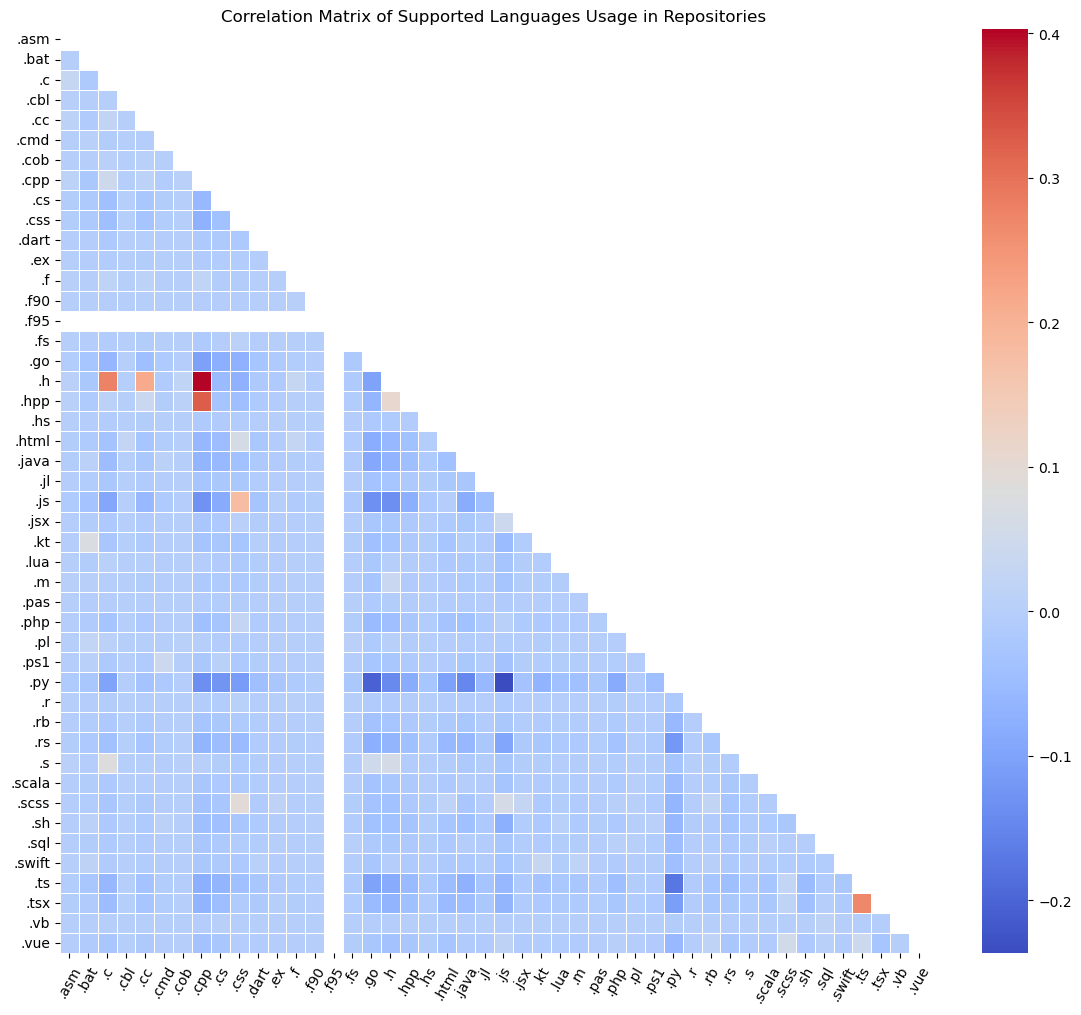

In [7]:
analytics.plot_language_correlation_matrix()

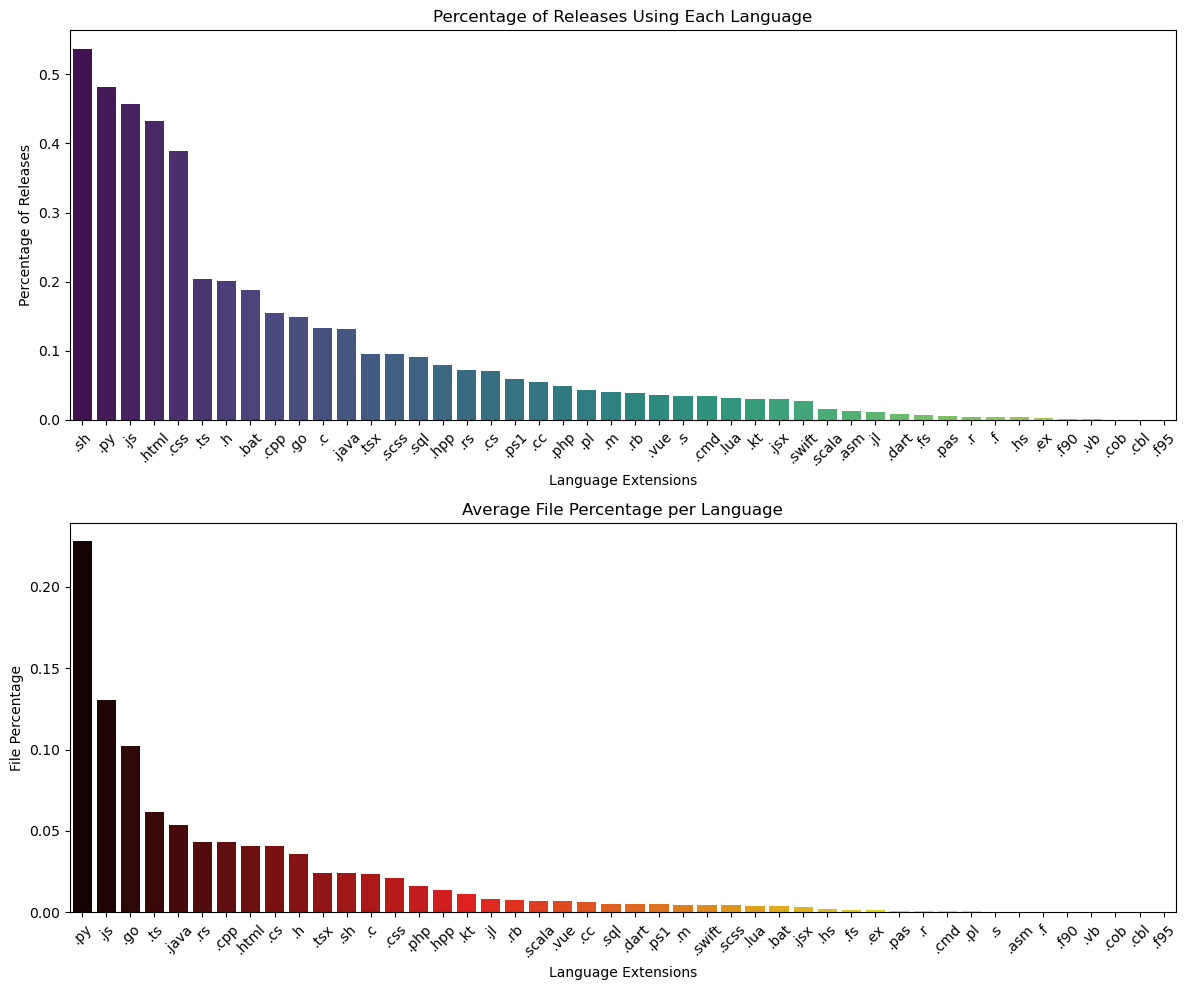

In [8]:
analytics.plot_language_percentage()

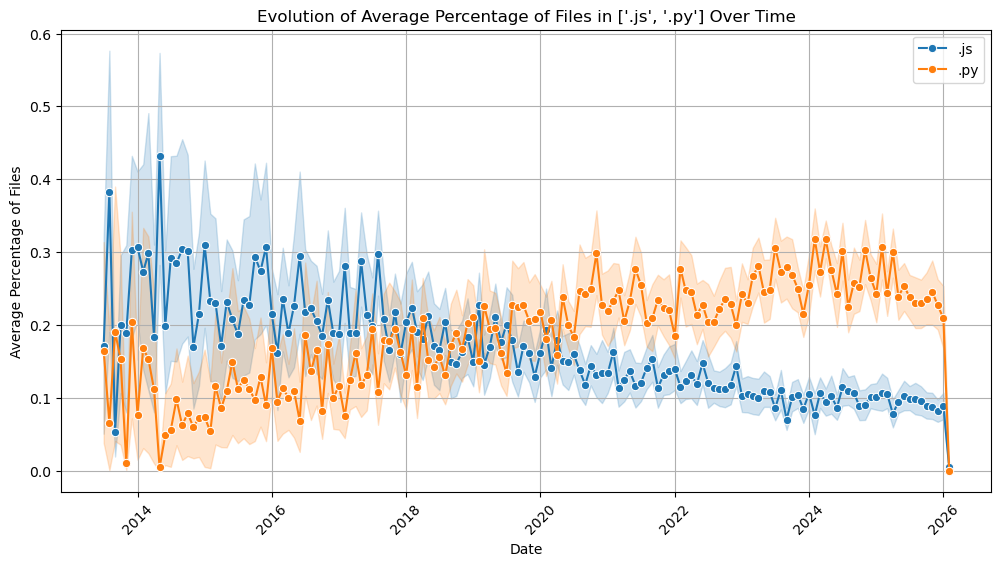

In [9]:
analytics.plot_language_evolution([".js", ".py"])

10 least used languages:
   language_extensions  language_usage_percentage
45                .f95                   0.000000
44                .cbl                   0.000019
43                .cob                   0.000152
42                 .vb                   0.000856
41                .f90                   0.001103
40                 .ex                   0.002834
39                 .hs                   0.003652
38                  .f                   0.004355
37                  .r                   0.004374
36                .pas                   0.005439


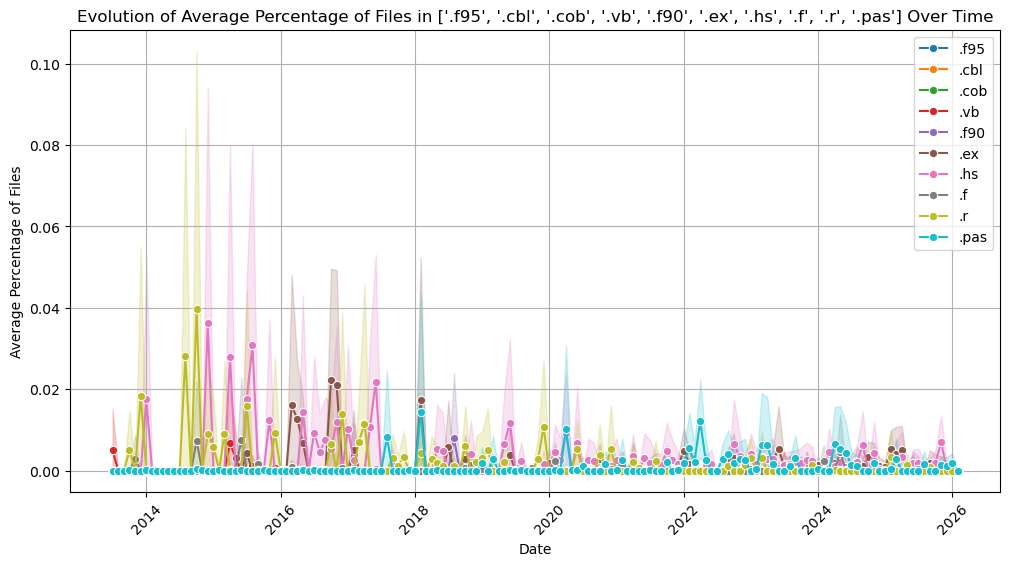

In [10]:
# Plot the 10 least used languages from the summary
least_used_languages = summary.sort_values(by="language_usage_percentage").head(10)
print("10 least used languages:")
print(least_used_languages[["language_extensions", "language_usage_percentage"]])

analytics.plot_language_evolution(least_used_languages["language_extensions"].tolist())

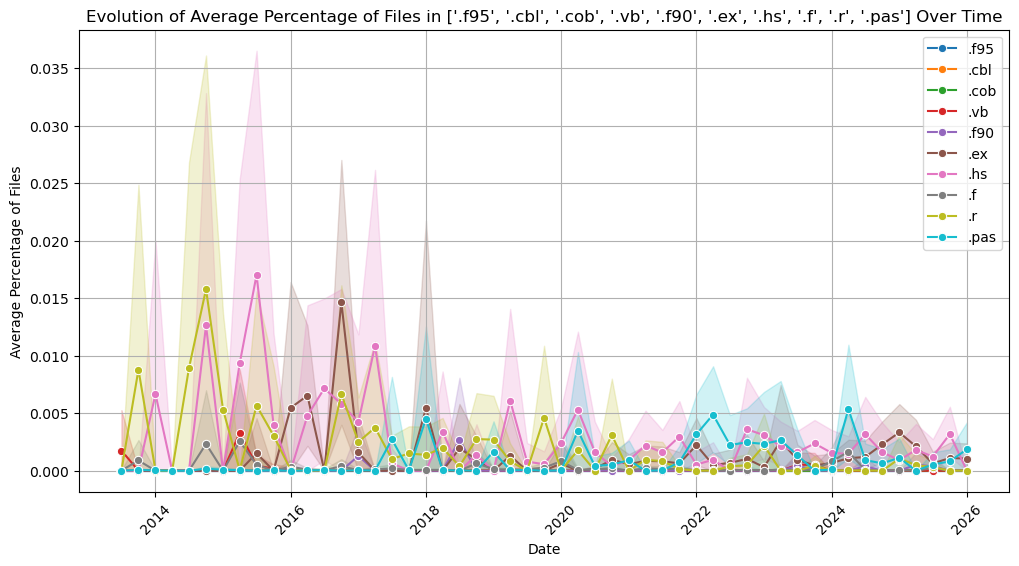

In [11]:
analytics.plot_language_evolution(least_used_languages["language_extensions"].tolist(), interval="Q")

10 most used languages:
  language_extensions  language_usage_percentage
0                 .sh                   0.536820
1                 .py                   0.481400
2                 .js                   0.457018
3               .html                   0.432199
4                .css                   0.389254
5                 .ts                   0.203252
6                  .h                   0.201027
7                .bat                   0.187353
8                .cpp                   0.154089
9                 .go                   0.148383


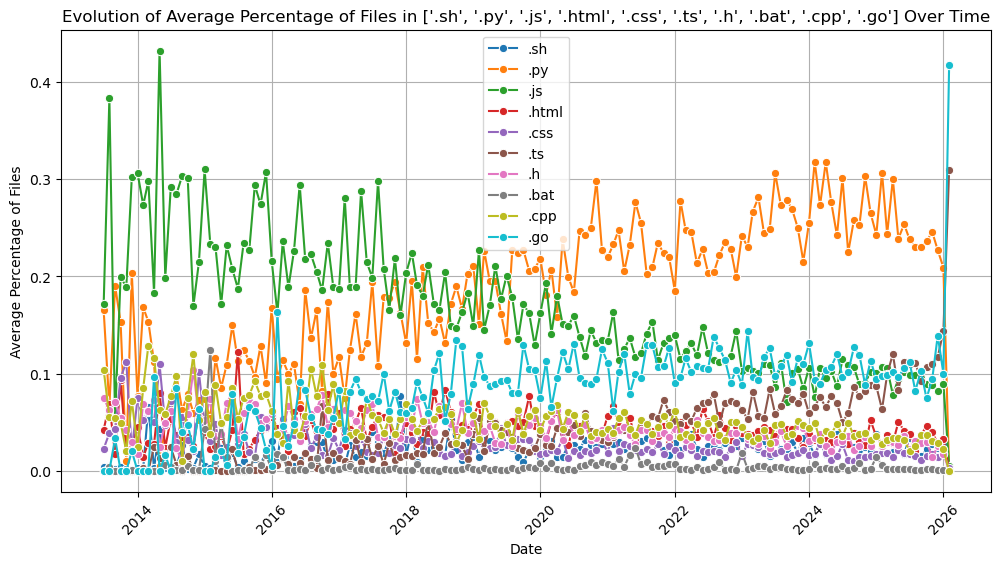

In [12]:
# Plot the 10 most used languages from the summary
most_used_languages = summary.sort_values(by="language_usage_percentage", ascending=False).head(10)
print("10 most used languages:")
print(most_used_languages[["language_extensions", "language_usage_percentage"]])

analytics.plot_language_evolution(most_used_languages["language_extensions"].tolist(), errorbar=None)

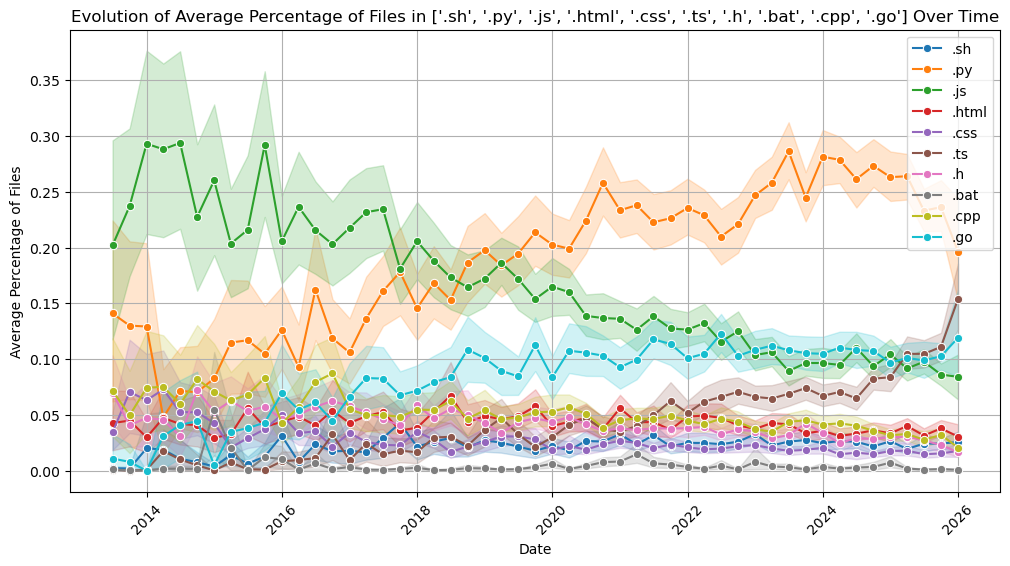

In [13]:
analytics.plot_language_evolution(most_used_languages["language_extensions"].tolist(), interval="Q")

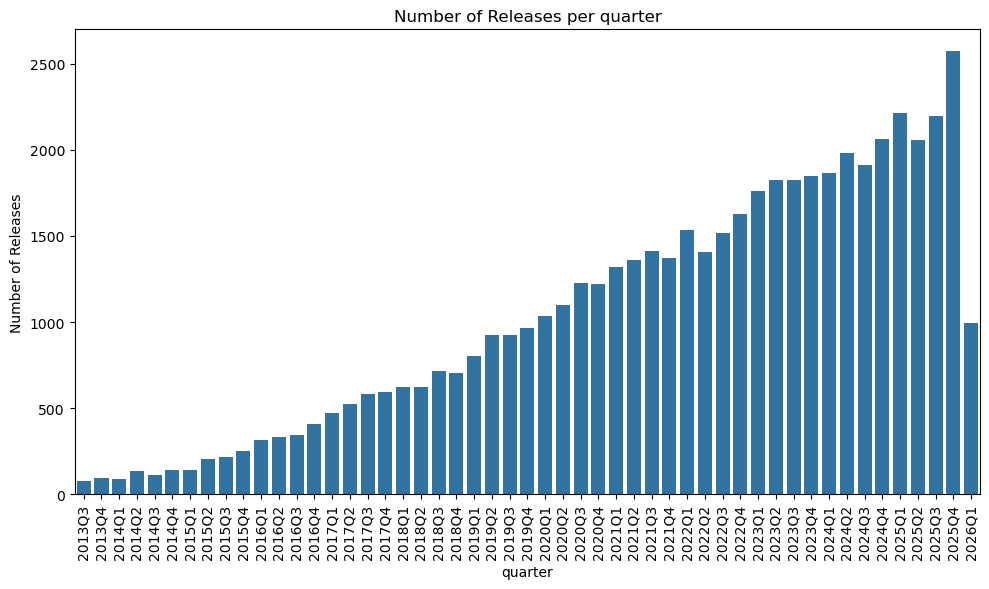

In [14]:
analytics.plot_releases_per_interval(interval="Q")

In [1]:

import pandas as pd
from prophet import Prophet

df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv')
df

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871


In [2]:
m = Prophet()
m.fit(df)

01:19:10 - cmdstanpy - INFO - Chain [1] start processing
01:19:11 - cmdstanpy - INFO - Chain [1] done processing


In [3]:
future = m.make_future_dataframe(periods=365)
future

,ds
0,2007-12-10
1,2007-12-11
2,2007-12-12
3,2007-12-13
4,2007-12-14
...,...
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18


In [4]:
forecast = m.predict(future)
forecast#[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()



,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2007-12-10,8.041708,8.248627,9.436463,8.041708,8.041708,0.802946,0.802946,0.802946,0.352288,0.352288,0.352288,0.450657,0.450657,0.450657,0.0,0.0,0.0,8.844654
1,2007-12-11,8.040161,7.967836,9.182233,8.040161,8.040161,0.553024,0.553024,0.553024,0.119636,0.119636,0.119636,0.433388,0.433388,0.433388,0.0,0.0,0.0,8.593185
2,2007-12-12,8.038615,7.724450,9.005658,8.038615,8.038615,0.350385,0.350385,0.350385,-0.066669,-0.066669,-0.066669,0.417054,0.417054,0.417054,0.0,0.0,0.0,8.389000
3,2007-12-13,8.037068,7.793003,8.987642,8.037068,8.037068,0.329846,0.329846,0.329846,-0.072254,-0.072254,-0.072254,0.402100,0.402100,0.402100,0.0,0.0,0.0,8.366914
4,2007-12-14,8.035522,7.719840,9.014777,8.035522,8.035522,0.319355,0.319355,0.319355,-0.069575,-0.069575,-0.069575,0.388931,0.388931,0.388931,0.0,0.0,0.0,8.354877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3265,2017-01-15,7.192195,7.454253,8.960563,6.819314,7.523828,1.017924,1.017924,1.017924,0.048287,0.048287,0.048287,0.969637,0.969637,0.969637,0.0,0.0,0.0,8.210119
3266,2017-01-16,7.191174,7.820145,9.281723,6.815523,7.524233,1.343970,1.343970,1.343970,0.352288,0.352288,0.352288,0.991682,0.991682,0.991682,0.0,0.0,0.0,8.535144
3267,2017-01-17,7.190152,7.616832,9.057153,6.811732,7.524638,1.132419,1.132419,1.132419,0.119636,0.119636,0.119636,1.012783,1.012783,1.012783,0.0,0.0,0.0,8.322571
3268,2017-01-18,7.189131,7.450153,8.875869,6.807090,7.525042,0.966070,0.966070,0.966070,-0.066669,-0.066669,-0.066669,1.032739,1.032739,1.032739,0.0,0.0,0.0,8.155201


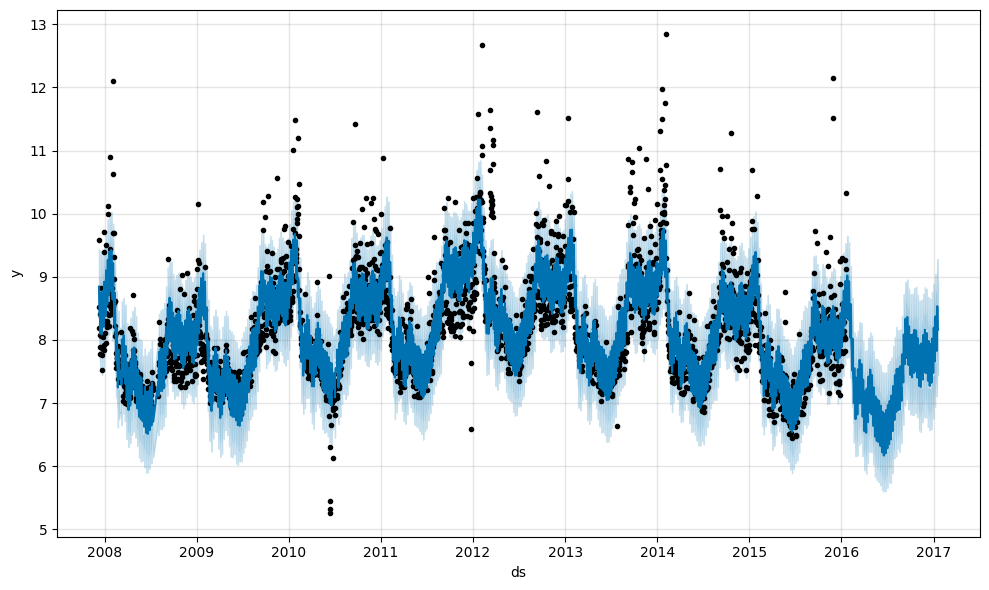

In [5]:
fig1 = m.plot(forecast)

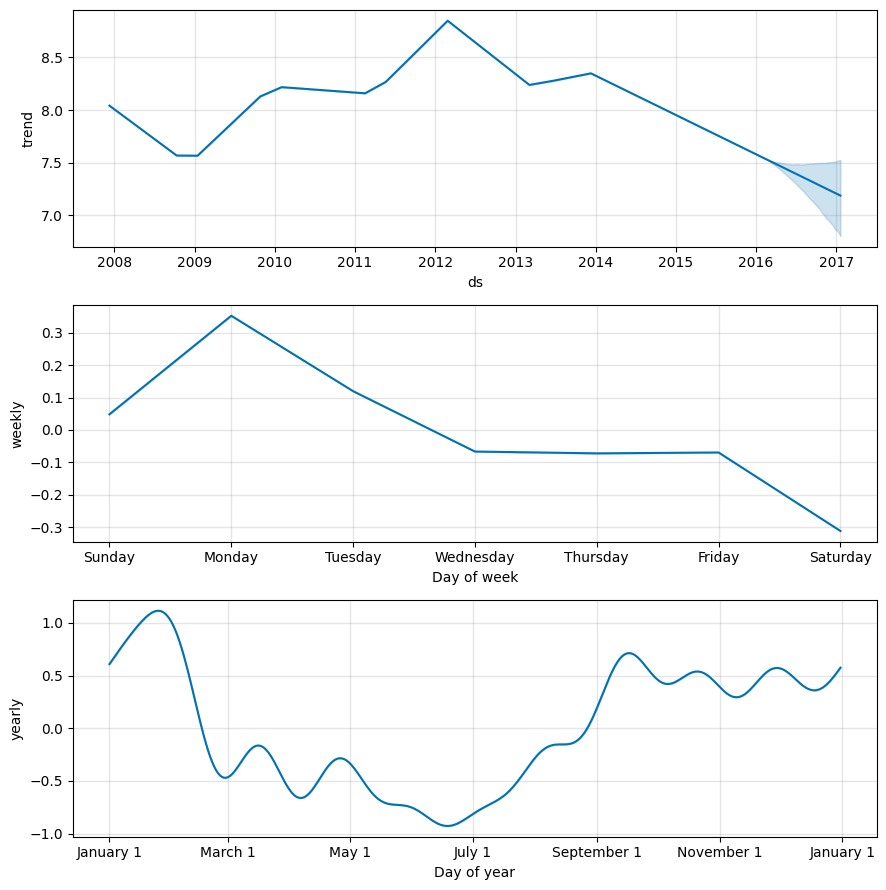

In [6]:
fig2 = m.plot_components(forecast)



In [7]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)